<a href="https://colab.research.google.com/github/saraeastough/SCI1500-Sara-Eastough-public/blob/main/Copy_of_Week01_Lab_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Lab: Functions and the Language of Scientific Analysis
**SCIE1500 — Analytical Methods for Scientists | Semester 2, 2026**

> **How this notebook works:** Read each section, then run the code cells in order by pressing **Shift + Enter** (or the ▶ button).
> Work through this as a group — discuss every answer before writing it down.
> If a cell gives an unexpected result, re-read the text above it before asking for help.

---
## 🌊 Scientific Scenario: Global Plastic Production

![Global plastic production data with rate of change trends](https://github.com/ahailu95/scie1500-content/blob/main/SCIE1500Materials/Week_1/images/W1_plastic_production.svg?raw=1)

The United Nations Environment Programme (UNEP) is preparing a report on plastic waste in oceans. You are part of a team analysing historical data on global plastic production.

**Data: Global plastic production (million tonnes)**

| Year | 1950 | 1970 | 1990 | 2010 | 2015 |
|------|------|------|------|------|------|
| Production (Mt) | 2 | 35 | 120 | 270 | 380 |

The relationship between year and production can be modelled as a function $P(t)$, where $t$ is years since 1950.

*Over the course of this lab you will:*
1. Build and interrogate this function mathematically
2. Visualise it in Python
3. Use it to evaluate an Australian policy question

---
## 🎯 Group Task & Learning Objectives

| Part | Time | You will be able to... |
|------|------|------|
| A | ~20 min | Define a mathematical function and state its domain and range; calculate and interpret average rates of change with units |
| B | ~15 min | Interpret slope to explain how growth changes across decades; plot a dataset and read trends from a graph |
| C | ~20 min | Write and call a Python function; apply it to analyse population growth and evaluate a policy scenario |

### Before you start: loading the tools

The cell below loads two Python libraries we need today:
- **numpy** (`np`): handles arrays of numbers and mathematical operations
- **matplotlib** (`plt`): creates plots and graphs

Run it now — you should see a short confirmation message. If you see an error instead, raise your hand.

In [ ]:
# Run this cell first — it loads the libraries we need throughout the lab
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Part A: Function Basics (~20 min)

### What is a function?

A **function** $f$ assigns to each valid input $x$ exactly one output $f(x)$.
We write: $f : \text{Domain} \to \text{Range}$

- The **domain** is the set of all valid inputs.
- The **range** is the set of all possible outputs.

For the plastic production data, we define:
$$P(t) = \text{production (million tonnes)}, \quad t = \text{years since 1950}$$

So $P(0) = 2$, $P(20) = 35$, $P(65) = 380$, etc.

### Loading the data into Python

Python stores sequences of numbers as **arrays** — you can think of them like a column of values in a spreadsheet. We use `np.array([...])` to create them.

Run the cell below. It creates two arrays (one for $t$, one for $P$) and prints them side by side so you can confirm the values match the table above.

The data from the UNEP report.

In [ ]:
# The data from the UNEP report
t_values = np.array([0, 20, 40, 60, 65])    # years since 1950
P_values = np.array([2, 35, 120, 270, 380])  # million tonnes

# Convert t back to calendar years for readability
years = 1950 + t_values

print("Year:       ", years)
print("t (yrs):    ", t_values)
print("P(t) (Mt):  ", P_values)

Year:        [1950 1970 1990 2010 2015]
t (yrs):     [ 0 20 40 60 65]
P(t) (Mt):   [  2  35 120 270 380]


### A.1 Average Rate of Change

The **average rate of change** of $P$ from $t = a$ to $t = b$ is:
$$\frac{P(b) - P(a)}{b - a}$$

This is the slope of the straight line joining the two points $(a, P(a))$ and $(b, P(b))$.
Its units here are: **million tonnes per year**.

We'll compute this for the full 65-year period (1950 to 2015) first.

**What to expect:** We're computing a single number — the average slope over 65 years. It tells us how fast production was growing *on average* across the whole period. Run the cell and read the result before moving on.

In [ ]:
# Average rate of change from 1950 to 2015 (t = 0 to t = 65)
P_1950 = 2     # P(0)
P_2015 = 380   # P(65)
delta_t = 65

avg_rate = (P_2015 - P_1950) / delta_t

# Raw output first — just the number
print("Average rate of change:", avg_rate)
print("Units: million tonnes per year")

Average rate of change: 5.815384615384615
Units: million tonnes per year


### A.2 Domain and Range

✏️ **Activity A.2 — Answer as a group:**

1. What is the **mathematical domain** of $P(t)$?
   *(All values of $t$ for which the formula is defined)*

2. What is the **physical domain**?
   *(Values of $t$ that make sense for plastic production — when did production start? Can $t$ be negative?)*

3. What is the approximate **range** of $P$ based on the data?

Write your answers in the cell below (use `#` to comment them out — Python will skip commented lines).

A.2 GROUP ANSWERS — replace the ... with your answers.

In [ ]:
# A.2 GROUP ANSWERS — replace the ... with your answers

# 1. Mathematical domain:
#    With each passing year, plastic production in tonnes increases exponentially. 0-65

# 2. Physical domain (realistic t values):
#    65 years. t can be negative.

# 3. Range of P based on the data:
#    2-380 million


---
## Part B: Interpreting Slope (~15 min)

The overall average rate from Part A (1950–2015) hides a lot of detail.
Does production grow at the same pace in every decade, or does the rate change over time?

**We'll find out by computing the average rate for each 20-year period separately.**

### B.1 — One decade by hand first

Before looking at all four periods at once, let's do the 1950–1970 calculation manually so the arithmetic is visible. This is the same formula as A.1, just applied to a shorter window.

Rate of change for 1950–1970 only (t = 0 to t = 20).

In [ ]:
# Rate of change for 1950–1970 only (t = 0 to t = 20)
P_at_0  = P_values[0]    # P(0)  — first element of the array
P_at_20 = P_values[1]    # P(20) — second element

rate_1950_70 = (P_at_20 - P_at_0) / (20 - 0)

print("Production in 1950:", P_at_0, "Mt")
print("Production in 1970:", P_at_20, "Mt")
print("Rate of change (1950-1970):", rate_1950_70, "Mt/yr")

Production in 1950: 2 Mt
Production in 1970: 35 Mt
Rate of change (1950-1970): 1.65 Mt/yr


### B.1 — All four periods

Now a **loop** repeats the same three-line calculation for each period automatically.
Each time through the loop, `t1`, `t2`, and `label` take the next row of values from the list.

The output uses `f"..."` — an *f-string* — to embed the variable values directly in text.
`:.2f` means "show 2 decimal places". You'll see this format again in later labs.

Calculate average rate of change for all four periods.

In [ ]:
# Calculate average rate of change for all four periods
periods = [
    (0,  20, '1950–1970'),
    (20, 40, '1970–1990'),
    (40, 60, '1990–2010'),
    (60, 65, '2010–2015'),
]

print(f"{'Period':<12}  {'Rate (Mt/yr)':>14}")
print("-" * 30)
for t1, t2, label in periods:
    P1 = P_values[t_values == t1][0]    # find P at t = t1
    P2 = P_values[t_values == t2][0]    # find P at t = t2
    rate = (P2 - P1) / (t2 - t1)
    print(f"  {label:<12}  {rate:>12.2f}")

Period          Rate (Mt/yr)
------------------------------
  1950–1970             1.65
  1970–1990             4.25
  1990–2010             7.50
  2010–2015            22.00


✏️ **Activity B.1 — Answer as a group:**

1. Is the rate of change constant across decades? What does this tell you about the shape of $P(t)$?

2. The 2010–2015 rate looks much higher than 1990–2010 — but can you trust this comparison?
   *(Hint: think about what the different time intervals mean for the calculation.)*

Write your answers below.

B.1 GROUP ANSWERS.

In [ ]:
# B.1 GROUP ANSWERS

# 1. Is the rate constant? What does this imply about the shape of P(t)?
#    No. Exponential growth.

# 2. Why might the 2010–2015 comparison be misleading?
#    Becuase the time interval between 2010-2015 is only 5 years compared to the other intervals which is 20 years. Meaning there could be anomalies within that 5 years period which wouldn't be noticed if it was a 20 year.


### B.2 Plotting P(t)

A graph often reveals patterns that a table of numbers hides. Let's plot the data.

**Reading the code below:**
- `fig, ax = plt.subplots()` — creates a blank figure and axes (canvas + coordinate system)
- `ax.scatter(...)` — draws the five data points as dots
- `ax.plot(...)` — draws connecting line segments between the points
- `ax.set_xlabel / ylabel / title` — labels the axes and adds a title

Run it, then look at the shape before answering the activity below.

Run the next cell.

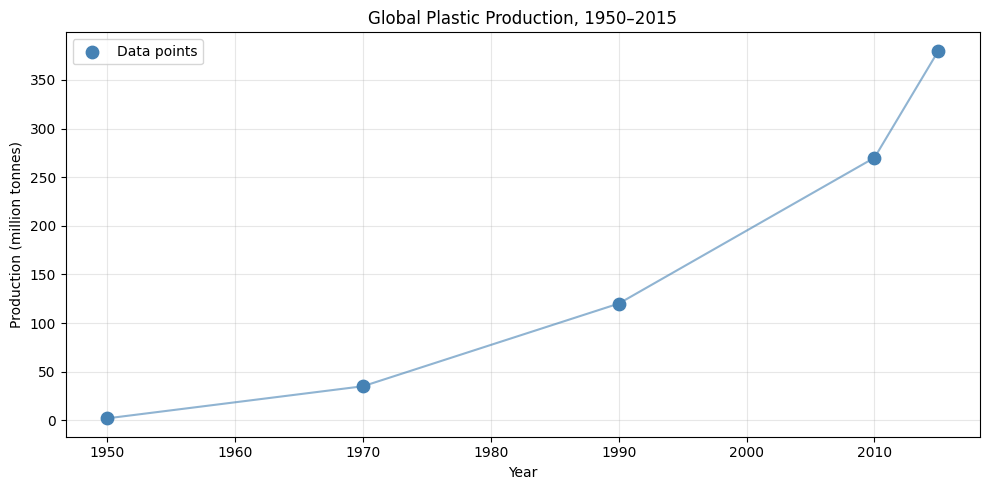

In [ ]:
fig, ax = plt.subplots()
ax.scatter(1950 + t_values, P_values, color='steelblue', s=80, zorder=5, label='Data points')
ax.plot(1950 + t_values, P_values, color='steelblue', linewidth=1.5, alpha=0.6)

ax.set_xlabel('Year')
ax.set_ylabel('Production (million tonnes)')
ax.set_title('Global Plastic Production, 1950–2015')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✏️ **Activity B.2 — Answer as a group:**
1. Does the graph look linear (straight) or curved? How does this match what the rates in B.1 told you?
2. If you extended this graph to 2030, what shape would you expect? Why?

```
Answers:
1. Curved. Because rate of change isn't constant.
2. Rate of change will continue to increase. Exponential change.
```

---
## Part C: Australian Policy Application (~20 min)

Now we apply what we know about functions and rates of change to a real policy question.

**Context:**
Australia's coastal population in 2010 was approximately 20 million, with each person generating 50 kg of plastic waste per year. Of this waste, **2% is mismanaged** (enters the ocean).

We'll work in three steps:
1. Calculate the baseline (how much waste enters the ocean in 2010)
2. Build a function $W(t)$ that projects this forward as population grows
3. Test whether a government policy reduces waste enough to make a difference

**Define $t$ = years since 2010 for this part.**

### Step 1: Baseline waste in 2010

Before building a model, let's compute the 2010 starting point in plain arithmetic — no functions yet. We multiply population × plastic per person × mismanagement rate, then convert kg to tonnes.

Given values.

In [ ]:
# Given values
population_2010 = 20e6       # 20 million people  (20e6 = 20,000,000)
plastic_per_person_kg = 50   # kg/person/year
mismanagement_rate = 0.02    # 2%

# Annual mismanaged plastic entering the ocean (kg, then convert to tonnes)
annual_waste_kg     = population_2010 * plastic_per_person_kg * mismanagement_rate
annual_waste_tonnes = annual_waste_kg / 1000

print("Annual mismanaged plastic (tonnes):", annual_waste_tonnes)
print("Daily mismanaged plastic (tonnes):", annual_waste_tonnes / 365)

Annual mismanaged plastic (tonnes): 20000.0
Daily mismanaged plastic (tonnes): 54.794520547945204


### Step 2: Writing the function W(t)

If Australia's coastal population grows at **1.5% per year**, then at time $t$ years after 2010:
$$\text{Population}(t) = 20{,}000{,}000 \times 1.015^t$$

✏️ **Activity C.1:** What is the full formula for $W(t)$, annual mismanaged plastic (tonnes/year), as a function of $t$?

In Python, `def` packages a formula under a name. Once defined, calling `W(10)` substitutes $t = 10$ and returns the result. The structure below already has the population formula — your job is to read it and confirm it matches what you expect.

W(0) should match the 2010 value you computed above.

In [ ]:
def W(t):
    'Annual mismanaged plastic waste (tonnes/year), t years after 2010.'
    population_t = 20e6 * 1.015**t                              # population grows 1.5%/yr
    waste = population_t * plastic_per_person_kg * mismanagement_rate / 1000  # kg -> tonnes
    return waste

# W(0) should match the 2010 value you computed above
print("W(0) =", W(0))      # baseline -- does it match?
print("W(10) =", W(10))    # projection for 2020
print("W(20) =", W(20))    # projection for 2030

W(0) = 20000.0
W(10) = 23210.81650050298
W(20) = 26937.100131001072


### Step 3: Testing the policy

The government proposes reducing the mismanagement rate from **2% to 0.5%** by 2030.
We define a second function $W_{\text{policy}}(t)$ — identical to $W(t)$ except for the mismanagement rate.

✏️ **Activity C.2:** Before running the cell, predict: will the policy bring 2030 waste *below* the 2010 level? Discuss with your group, then check.

Compare at 2030 (t = 20).

In [ ]:
def W_policy(t):
    'Annual mismanaged waste (tonnes/year) under the 0.5% policy.'
    population_t   = 20e6 * 1.015**t
    policy_rate    = 0.005      # 0.5% — the only change from W(t)
    waste = population_t * plastic_per_person_kg * policy_rate / 1000
    return waste

# Compare at 2030 (t = 20)
t_2030 = 20
print(f"Business as usual in 2030:    {W(t_2030):>10,.0f} tonnes/year")
print(f"Policy scenario in 2030:      {W_policy(t_2030):>10,.0f} tonnes/year")
print(f"2010 baseline:                {W(0):>10,.0f} tonnes/year")
print()
diff = W_policy(t_2030) - W(0)
direction = "above" if diff > 0 else "below"
print(f"Policy 2030 is {abs(diff):,.0f} tonnes/year {direction} the 2010 baseline.")

# The reduction is compounded.

Business as usual in 2030:        26,937 tonnes/year
Policy scenario in 2030:           6,734 tonnes/year
2010 baseline:                    20,000 tonnes/year

Policy 2030 is 13,266 tonnes/year below the 2010 baseline.


✏️ **Group discussion — write your conclusion below:**

Does the 2% → 0.5% reduction fully offset the effect of 1.5%/year population growth?
What does this suggest about the effectiveness of mismanagement-reduction policies alone?

GROUP CONCLUSION.

In [ ]:
# GROUP CONCLUSION

# Does the policy fully offset population growth? (yes / no / partially)
#    Yes

# In one sentence, what does this imply for ocean plastic policy?
#    The rate offsets the population growth.


### C.3 Visualise the Two Scenarios

The plot below shows both trajectories from 2010 to 2040. Look for:
- Where the two lines diverge (the effect of the policy kicks in immediately)
- Whether the policy line ever drops back to the 2010 baseline (horizontal dashed line)

Mark the 2010 baseline for reference.

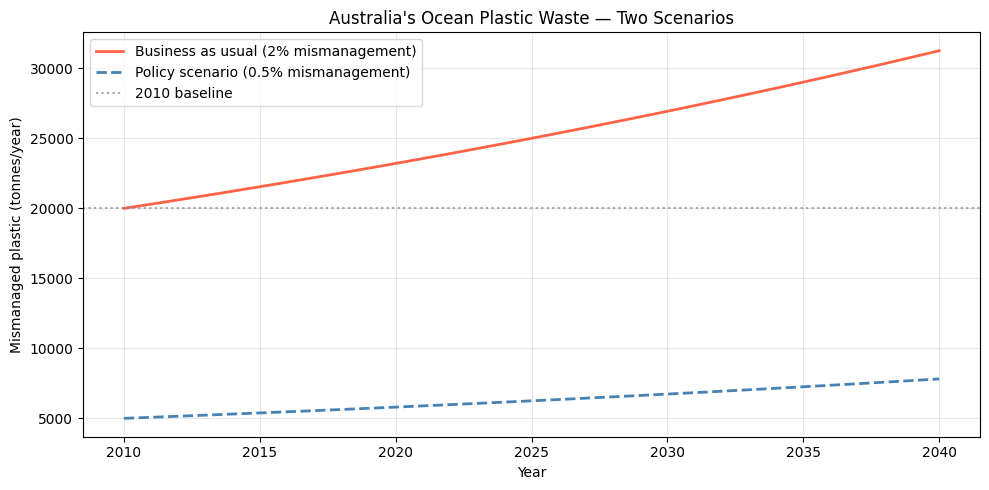

In [ ]:
t_range = np.linspace(0, 30, 100)

fig, ax = plt.subplots()
ax.plot(2010 + t_range, [W(t) for t in t_range],
        label='Business as usual (2% mismanagement)', color='tomato', linewidth=2)
ax.plot(2010 + t_range, [W_policy(t) for t in t_range],
        label='Policy scenario (0.5% mismanagement)', color='steelblue', linewidth=2, linestyle='--')

# Mark the 2010 baseline for reference
ax.axhline(W(0), color='gray', linestyle=':', alpha=0.7, label='2010 baseline')

ax.set_xlabel('Year')
ax.set_ylabel('Mismanaged plastic (tonnes/year)')
ax.set_title("Australia's Ocean Plastic Waste — Two Scenarios")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## ✅ Lab Wrap-Up

Before finishing, check that your group has:

- [ ] Stated the domain and range of $P(t)$ (Part A)
- [ ] Calculated rates of change for all four periods and explained the pattern (Part B)
- [ ] Written and tested the function $W(t)$ in Python (Part C)
- [ ] Compared the two policy scenarios with a plot (Part C)
- [ ] Written a group conclusion about the policy effectiveness (Part C)

**Self-check questions (discuss — no submission needed):**

1. Can a relation assign two different outputs to the same input and still be a function? Why / why not?
2. The slope from 1950–1970 is much lower than from 1990–2010. Does this mean plastic wasn't a problem in the 1950s?
3. What additional data would you need to make $W(t)$ more accurate?

> **Next week:** We'll study exponential and logarithmic models — which turn out to describe
> plastic production far better than a linear model does.